### Import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from src.feature_engineering import get_modeling_data, create_features

### 1. Data loading

In [3]:
df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
df.shape

(100000, 40)

### 2. Dataset validation

In [4]:
X, y, entity_df, categorical_cols, numerical_cols = get_modeling_data(df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud rate:", round(y.mean(), 4))
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

X shape: (100000, 39)
y shape: (100000,)
Fraud rate: 0.0333
Categorical: 7
Numerical: 32


In [5]:
entity_df.head()

,transaction_id,customer_id,merchant_id,device_id
0,TXN_0000001,CUST_000861,MERCH_00441,DEV_002799
1,TXN_0000002,CUST_003773,MERCH_00414,DEV_013863
2,TXN_0000003,CUST_003093,MERCH_00269,DEV_010056
3,TXN_0000004,CUST_000467,MERCH_00191,DEV_001720
4,TXN_0000005,CUST_004427,MERCH_00257,DEV_014495


In [8]:
X.columns

Index(['transaction_type', 'merchant_category', 'transaction_amount',
       'channel', 'device_type', 'transaction_city', 'merchant_risk_score',
       'hour', 'day_of_week', 'is_weekend', 'customer_home_city',
       'customer_tenure_days', 'account_age_days', 'preferred_device_type',
       'avg_amount_30d', 'std_amount_30d', 'transactions_last_7d',
       'declines_last_30d', 'chargebacks_last_90d', 'amount_vs_avg_ratio',
       'is_high_amount', 'is_very_high_amount', 'is_night_transaction',
       'is_high_risk_merchant', 'is_new_device', 'is_foreign_transaction',
       'channel_risk', 'category_risk', 'high_amount_new_device',
       'foreign_high_risk_merchant', 'web_night_transaction',
       'very_high_amount_foreign', 'log_transaction_amount', 'txn_velocity',
       'customer_risk_score', 'decline_ratio', 'amount_merchant_risk',
       'is_new_customer', 'abnormal_activity'],
      dtype='object')

In [9]:
X.head()

,transaction_type,merchant_category,transaction_amount,channel,device_type,transaction_city,merchant_risk_score,hour,day_of_week,is_weekend,...,foreign_high_risk_merchant,web_night_transaction,very_high_amount_foreign,log_transaction_amount,txn_velocity,customer_risk_score,decline_ratio,amount_merchant_risk,is_new_customer,abnormal_activity
0,card,fuel,42.32,pos,ios,Jersey City,0.203,11,6,1,...,0,0,0,3.768614,2.571429,4.5,0.157895,8.59096,0,0
1,digital_payment,fashion,57.90,web,android,Los Angeles,0.514,18,3,0,...,0,0,0,4.075841,2.000000,0.5,0.066667,29.76060,0,0
2,digital_payment,restaurants,29.67,pos,android,Queens,0.313,6,2,0,...,0,0,0,3.423285,2.000000,2.0,0.066667,9.28671,0,0
3,digital_payment,grocery,52.43,app,android,Jersey City,0.100,18,0,0,...,0,0,0,3.978372,1.428571,5.0,0.363636,5.24300,0,0
4,digital_payment,gaming,64.67,web,android,Los Angeles,0.377,15,5,1,...,0,0,0,4.184642,2.142857,3.5,0.250000,24.38059,0,0


In [10]:
"fraud_probability" in X.columns, "fraud_risk_score" in X.columns

(False, False)

In [11]:
X[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_amount,100000.0,52.252057,52.900465,1.630000,25.570000,37.080000,57.370000,2091.480000
merchant_risk_score,100000.0,0.360334,0.221065,0.030000,0.180000,0.316000,0.494000,0.950000
hour,100000.0,11.485300,6.936697,0.000000,5.000000,11.000000,18.000000,23.000000
day_of_week,100000.0,3.006460,1.999530,0.000000,1.000000,3.000000,5.000000,6.000000
is_weekend,100000.0,0.287060,0.452392,0.000000,0.000000,0.000000,1.000000,1.000000
customer_tenure_days,100000.0,1823.067750,1031.758911,30.000000,931.000000,1823.000000,2709.000000,3649.000000
account_age_days,100000.0,1827.328780,1040.382913,31.000000,941.000000,1841.000000,2719.000000,3649.000000
avg_amount_30d,100000.0,133.379371,68.183062,15.010000,74.110000,134.570000,192.380000,249.930000
std_amount_30d,100000.0,43.129536,21.768241,5.000000,24.110000,43.380000,62.390000,80.000000
transactions_last_7d,100000.0,12.371570,6.842772,1.000000,6.000000,12.000000,18.000000,24.000000


In [12]:
X[categorical_cols].nunique().sort_values(ascending=False)

merchant_category        8
transaction_city         7
customer_home_city       6
channel                  3
device_type              3
preferred_device_type    3
transaction_type         2
dtype: int64

### 3. Directed EDA
Quick exploratory checks to validate dataset structure and fraud patterns.

In [13]:
# Target Distribution
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.9667
1    0.0333
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Fraud Distribution')

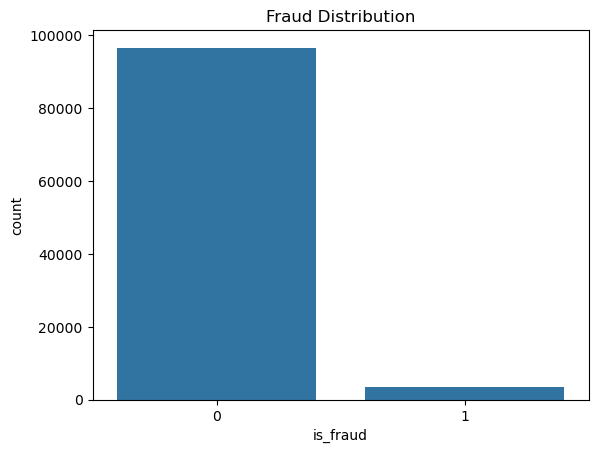

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="is_fraud")
plt.title("Fraud Distribution")

Text(0.5, 1.0, 'Transaction Amount Distribution')

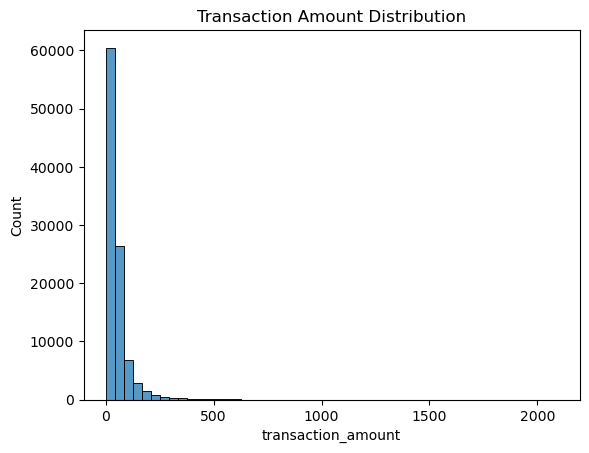

In [15]:
# Amount Distribution
sns.histplot(df["transaction_amount"], bins=50)
plt.title("Transaction Amount Distribution")

Text(0.5, 1.0, 'Log Transaction Amount')

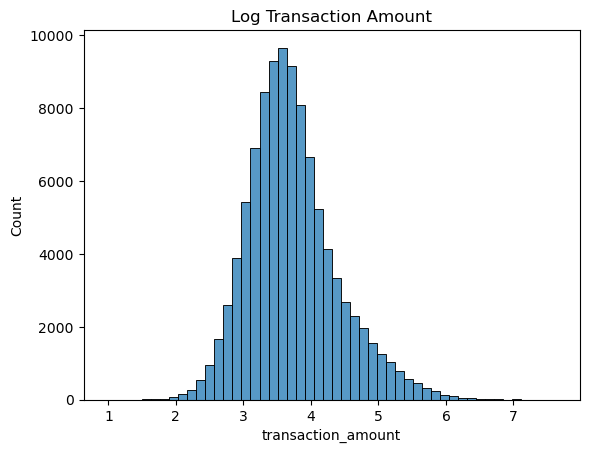

In [16]:
import numpy as np

sns.histplot(np.log1p(df["transaction_amount"]), bins=50)
plt.title("Log Transaction Amount")

Text(0.5, 1.0, 'Fraud Rate by Channel')

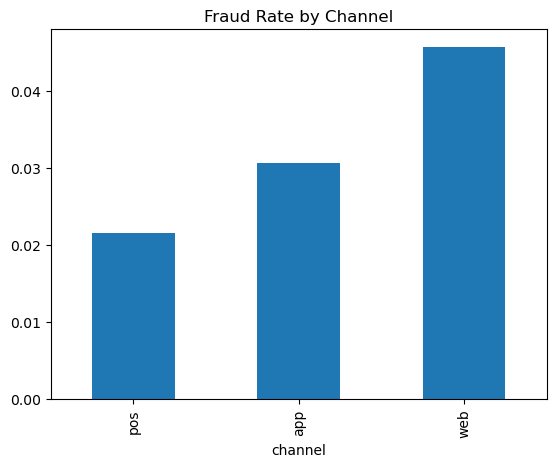

In [17]:
# Fraud rate by chanel 

df.groupby("channel")["is_fraud"].mean().sort_values().plot(kind="bar")
plt.title("Fraud Rate by Channel")

Text(0.5, 1.0, 'Fraud Rate by Merchant Category')

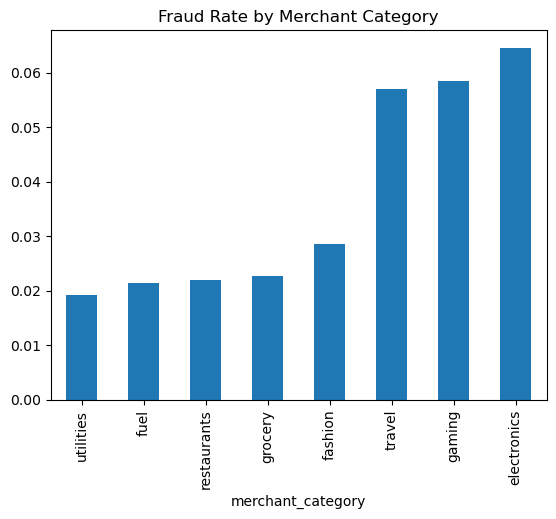

In [18]:
# Fraud Rate by Merchant Category
df.groupby("merchant_category")["is_fraud"].mean().sort_values().plot(kind="bar")
plt.title("Fraud Rate by Merchant Category")

<Axes: xlabel='is_fraud', ylabel='transaction_amount'>

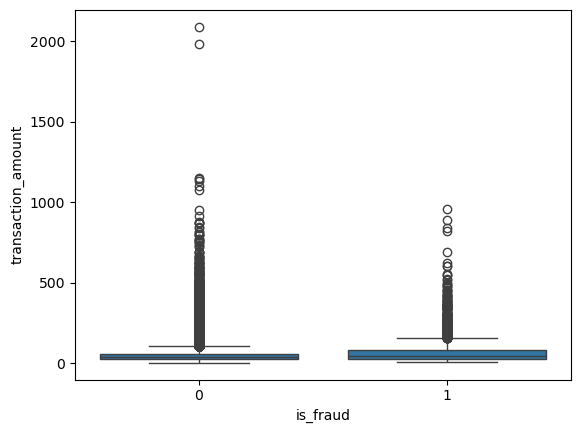

In [19]:
# Fraud Vs Amount
sns.boxplot(x="is_fraud", y="transaction_amount", data=df)

### 4. Additional Feature Engineering

To enrich the dataset and better capture potential fraud patterns, we create several additional features inspired by common fraud detection signals used in financial systems.

These features attempt to capture abnormal transaction behavior, customer risk indicators, and interactions between transaction value and merchant risk.

**New Features**

- **log_transaction_amount**  
  Log transformation of the transaction amount to reduce the effect of extreme values and stabilize the distribution. Financial transaction data typically exhibits a heavy right tail.

- **txn_velocity**  
  Average number of transactions per day over the last week. Sudden increases in transaction velocity can indicate account takeover or bot activity.

- **customer_risk_score**  
  Composite score based on historical declines and chargebacks associated with the customer. Previous failed transactions and disputes are often predictive of future fraud risk.

- **decline_ratio**  
  Ratio of declined transactions to recent transaction activity. A high ratio may indicate suspicious activity such as repeated attempts using invalid payment methods.

- **amount_merchant_risk**  
  Interaction between transaction amount and merchant risk score. High-value transactions at high-risk merchants are more likely to be fraudulent.

- **is_new_customer**  
  Binary indicator identifying recently created accounts (tenure < 90 days). Fraud often targets newly created or weakly verified accounts.

- **abnormal_activity**  
  Flag indicating unusually high transaction activity combined with transaction amounts significantly above the customer's historical average.

In [18]:
import numpy as np

# Log transformation of transaction amount
# Reduces skewness and stabilizes heavy-tailed financial distributions
df["log_transaction_amount"] = np.log1p(df["transaction_amount"])

# Transaction velocity
# Average number of transactions per day in the last week
# Sudden spikes in velocity may indicate automated or fraudulent activity
df["txn_velocity"] = df["transactions_last_7d"] / 7

# Customer risk score
# Combines previous declined transactions and chargebacks
# Customers with prior disputes or declines tend to exhibit higher fraud risk
df["customer_risk_score"] = (
    df["declines_last_30d"] * 0.5 +
    df["chargebacks_last_90d"] * 1.5
)

# Decline ratio
# Measures the proportion of declined transactions relative to recent activity
# High ratios may indicate repeated attempts using invalid payment credentials
df["decline_ratio"] = df["declines_last_30d"] / (df["transactions_last_7d"] + 1)

# Interaction between transaction amount and merchant risk
# High-value purchases at risky merchants are more suspicious
df["amount_merchant_risk"] = df["transaction_amount"] * df["merchant_risk_score"]

# New customer indicator
# Fraud is frequently associated with newly created accounts
df["is_new_customer"] = (df["customer_tenure_days"] < 90).astype(int)

# Abnormal activity flag
# Captures unusually high activity combined with spending above historical behavior
df["abnormal_activity"] = (
    (df["transactions_last_7d"] > 15) &
    (df["amount_vs_avg_ratio"] > 2)
).astype(int)


In [19]:
df.head()

,transaction_id,customer_id,timestamp,transaction_type,merchant_category,transaction_amount,merchant_id,channel,device_type,device_id,...,fraud_risk_score,fraud_probability,is_fraud,log_transaction_amount,txn_velocity,customer_risk_score,decline_ratio,amount_merchant_risk,is_new_customer,abnormal_activity
0,TXN_0000001,CUST_000861,2025-02-02 11:00:00,card,fuel,42.32,MERCH_00441,pos,ios,DEV_002799,...,-3.043349,0.008191,0,3.768614,2.571429,4.5,0.157895,8.59096,0,0
1,TXN_0000002,CUST_003773,2025-10-09 18:00:00,digital_payment,fashion,57.90,MERCH_00414,web,android,DEV_013863,...,-1.663994,0.028661,1,4.075841,2.000000,0.5,0.066667,29.76060,0,0
2,TXN_0000003,CUST_003093,2025-08-27 06:00:00,digital_payment,restaurants,29.67,MERCH_00269,pos,android,DEV_010056,...,-3.387342,0.005885,0,3.423285,2.000000,2.0,0.066667,9.28671,0,0
3,TXN_0000004,CUST_000467,2025-06-09 18:00:00,digital_payment,grocery,52.43,MERCH_00191,app,android,DEV_001720,...,-2.320802,0.016095,0,3.978372,1.428571,5.0,0.363636,5.24300,0,0
4,TXN_0000005,CUST_004427,2025-06-07 15:00:00,digital_payment,gaming,64.67,MERCH_00257,web,android,DEV_014495,...,-1.532862,0.031964,0,4.184642,2.142857,3.5,0.250000,24.38059,0,0


In [20]:
df.shape

(100000, 47)

In [20]:
set([
"log_transaction_amount",
"txn_velocity",
"customer_risk_score",
"decline_ratio",
"amount_merchant_risk",
"is_new_customer",
"abnormal_activity"
]).issubset(set(X.columns))

True

In [21]:
X.shape

(100000, 39)